In [80]:
from pathlib import Path

out = Path('../2020-09-25').resolve()

In [81]:
import json
import re
import numpy as np 

scores = {}
genomes = {}
rs = []
rows = []
for p in out.iterdir():
    if p.suffix == '':
        g = re.search('gen_0*(\d+)', str(p)).groups()[0]
        genomes[g] = {re.search('sim_0*(\d+)', str(i)).groups()[0]: json.load((p/i/'genome.json').open())['thresholds'] for i in p.iterdir() if i.suffix == ''}
        print(genomes[g].keys())
        for k in range(64):
            b = genomes[g][str(k)]['up']
            try:
                d = np.array(json.load((p/f'sim_{int(k):03}'/'data.json').open()))
                rs.extend([[g, k, b, t, f] for t, f in d])
            except:
                pass

dict_keys(['56', '51', '58', '60', '34', '33', '5', '2', '61', '59', '50', '57', '3', '4', '32', '35', '28', '17', '10', '19', '26', '21', '44', '43', '20', '18', '27', '11', '29', '16', '42', '45', '30', '37', '8', '1', '6', '39', '52', '55', '63', '7', '38', '0', '36', '9', '31', '62', '54', '53', '49', '40', '47', '13', '14', '22', '25', '46', '41', '48', '24', '23', '15', '12'])


In [105]:
good = json.load((out/'gen_001/good_sims.json').open())

In [107]:
g = [i[0] for i in good]

In [112]:
np.array(g).mean()

6354.158131073931

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
df = pd.DataFrame(rs, columns=['gen', 'sim', 'threshold', 't', 'fitness'])

In [90]:
genomes['1']['10']

{'up': 4890.065907366632, 'down': 0}

In [102]:
df.loc[df.t.gt(40000)].groupby('sim').fitness.mean().sort_values(ascending=False)

sim
59    69.718956
8     63.700429
62    62.201813
10    60.390252
6     53.764296
        ...    
16    26.655914
44    25.304213
51    24.860167
28    24.387914
63    23.594486
Name: fitness, Length: 64, dtype: float64

In [100]:
df.loc[df.sim.eq(58)].fitness.mean()

30.16321020116756

In [113]:
df.groupby('sim').agg({'threshold': 'first'}).sort_values(by='threshold', ascending=False)[:50]

,threshold
sim,
22,14820.377883
21,14523.492849
27,13769.915882
15,13624.993381
8,13609.440504
26,13488.208404
52,13116.440523
59,13022.167837
40,12984.692595


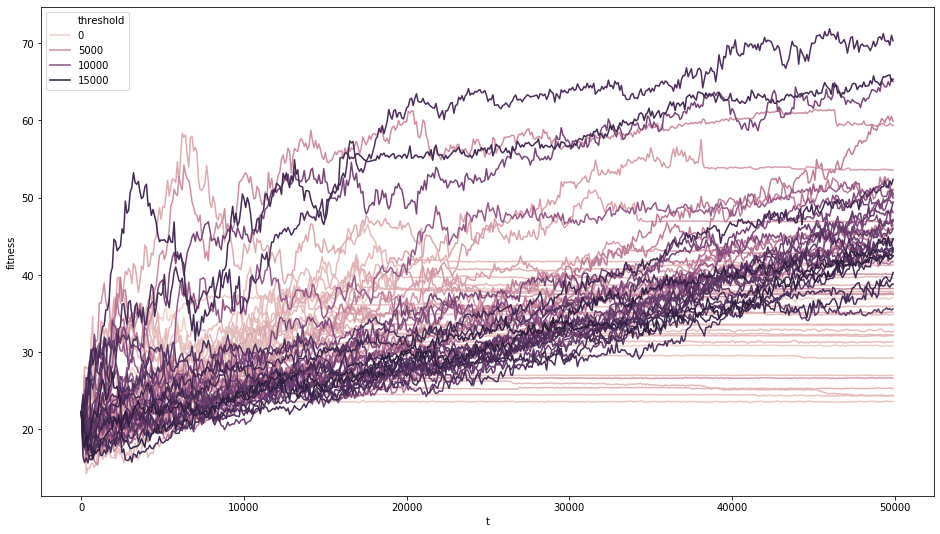

In [84]:
fig, ax = plt.subplots()
sns.lineplot('t', 'fitness', hue='threshold', data=df)
fig.set_size_inches(16, 9)
plt.savefig('single_thresh_fitnesses', dpi=600)

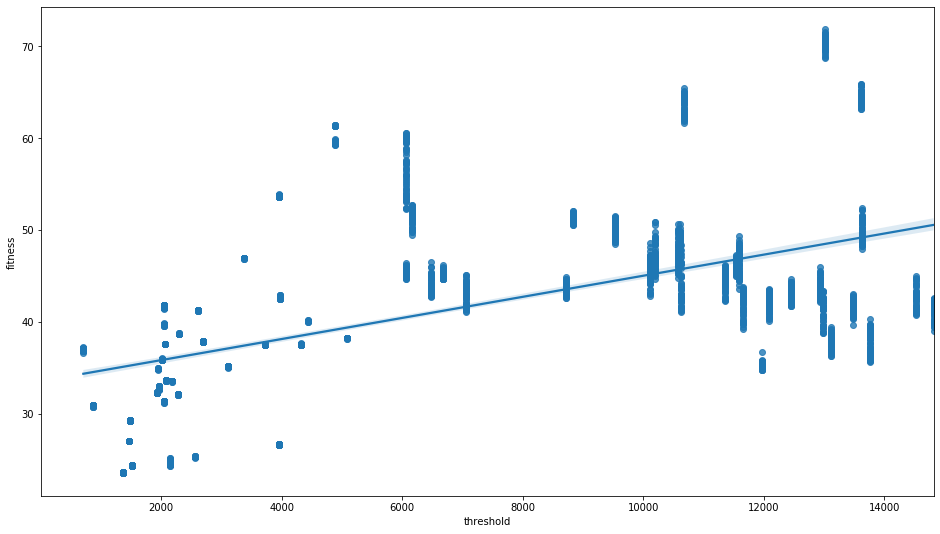

In [79]:
fig, ax = plt.subplots()
sns.regplot('threshold', 'fitness', data=df.loc[df.t.gt(45000)])
fig.set_size_inches(16, 9)
plt.savefig('f_over_single_threshold', dpi=600)

In [58]:
df.sim.unique().size

72

In [15]:
gdf = df.groupby(['gen', 'sim']).aggregate({'fitness': 'mean', 'beta': 'first'}).reset_index()

SpecificationError: nested renamer is not supported

In [18]:
gdf

,gen,sim,fitness,beta,epsilon
0,1,0,0.892323,-2820.019741,1392.116810
1,1,1,0.623379,-5284.090333,312.652682
2,1,10,0.642103,-9652.586928,200.673652
3,1,100,0.899055,1174.831771,286.749889
4,1,101,0.728853,-4674.813786,1323.714252
...,...,...,...,...,...
1019,4,95,0.887178,3256.724136,1069.116742
1020,4,96,0.895571,3255.705092,1067.702465
1021,4,97,0.869036,3256.650356,1070.433634
1022,4,98,0.889951,3255.853809,1069.856663


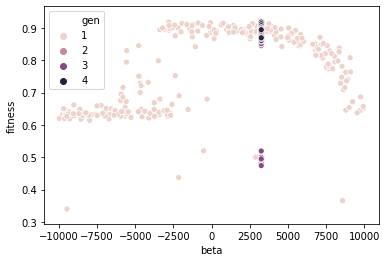

In [19]:
sns.scatterplot(data=gdf, x='beta', y='fitness', hue='gen')

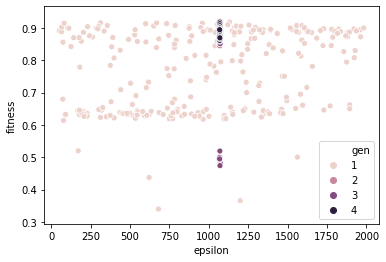

In [20]:
sns.scatterplot(data=gdf, x='epsilon', y='fitness', hue='gen')

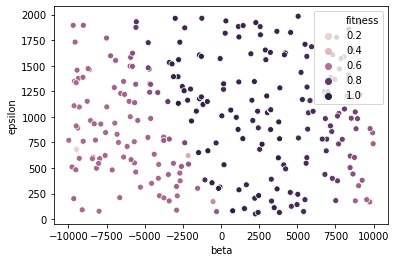

In [21]:
sns.scatterplot(data=gdf, x='beta', y='epsilon', hue='fitness')

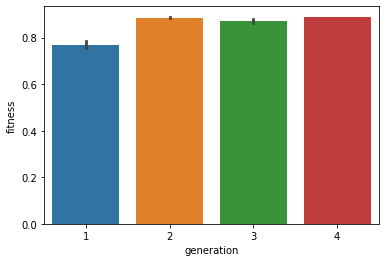

In [23]:
sns.barplot(x='gen', y='fitness', data=gdf)
plt.xlabel('generation')
plt.savefig('f_over_g', dpi=600)

In [14]:
gdf.head()

,gen,sim,fitness,beta
0,1,0,0.084550,11621.882456
1,1,1,-0.040482,11998.275805
2,1,10,0.833253,-1471.484801
3,1,100,-0.011785,-16420.813019
4,1,101,-0.321470,19990.167407


In [29]:
Fmu = gdf.fitness.mean()
gdf.loc[gdf.fitness.ge(Fmu), 'good'] = True
gdf.loc[gdf.fitness.lt(Fmu), 'good'] = False

In [30]:
golden = (1 + 5 ** 0.5) / 2

In [37]:
for gen, gendf in gdf.groupby('gen'):
    Nmu = gendf.loc[gendf.good.eq(True)].beta.mean()
    Nsd = np.ptp(gendf.loc[gendf.good.eq(True)].beta)/4
    newbetas = np.random.normal(Nmu, Nsd, 500)
    fig = sns.scatterplot(data=gendf, hue='good', x='beta', y='fitness')
    plt.annotate('ave fitness', (-20000, gendf.fitness.mean()+.05), color='m')
    ax = fig.axes
    ax.hlines(y=gendf.fitness.mean(), xmin=-20000, xmax=20000, ls='--', color='m')
    ax.vlines(x=Nmu, ymin=gendf.fitness.min(), ymax=gendf.fitness.max(), ls='--', color='g')
    fig = sns.distplot(newbetas, hist=False, ax=ax.twinx(), color='g')
    fig.axes.set_axis_off()
    ax.get_legend().remove()
    plt.title(f'generation {gen}')
    plt.savefig(f'dists/gen{gen}', dpi=600, bbox_inches='tight')
    plt.close()

In [260]:
gdf.sort_values(by='fitness', ascending=False).head(20)

,gen,sim,fitness,beta,good
84,1,85,0.870904,1940.258163,True
72,1,74,0.870371,-104.331805,True
58,1,61,0.869445,2824.234391,True
16,1,23,0.868272,1203.974880,True
25,1,31,0.866114,-2239.059832,True
7,1,15,0.864706,2559.167456,True
66,1,69,0.863454,4943.954840,True
79,1,80,0.863023,2583.413183,True
6,1,14,0.859573,275.630518,True
75,1,77,0.856235,-1713.722877,True


In [47]:
gdf[gdf.beta.lt(-6000)].head()

,gen,sim,fitness,beta
2,1,10,0.004740,-6969.425531
9,1,17,-0.013157,-6353.147098
10,1,18,-0.006209,-6733.394939
20,1,27,0.001238,-6204.674645
26,1,32,-0.014311,-7602.714283


In [49]:
gdf[gdf.beta.gt(15000)].head()

,gen,sim,fitness,beta
75,2,33,-0.278366,15094.869713
124,3,34,-0.291513,15773.605347
242,6,10,-0.294318,15276.550890
384,9,0,-0.315748,16959.136791


In [48]:
gdf[gdf.beta.ge(0) & gdf.beta.lt(5000)].head()

,gen,sim,fitness,beta
0,1,0,0.879442,1660.074403
4,1,12,0.872836,73.417575
5,1,13,0.848398,699.459059
18,1,25,0.870141,4401.076279
27,1,33,0.854063,2137.795601


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

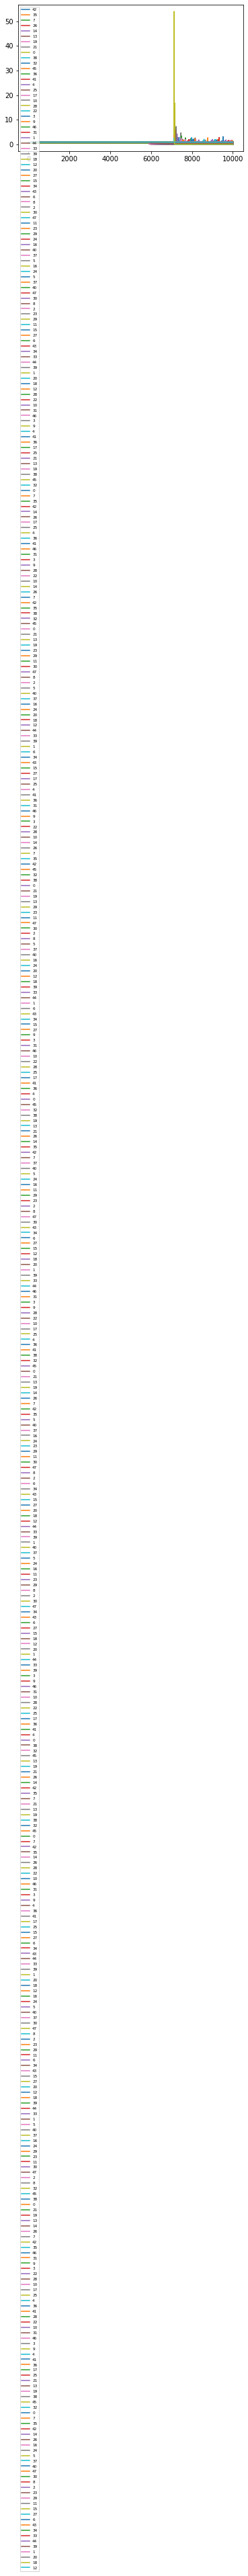

In [7]:
import numpy as np
for g in datas:
    for s in datas[g]:
        d = np.array(datas[g][s])
        plt.plot(d[:, 0], d[:, 1], label=s)
    plt.legend(loc='upper left', fontsize='xx-small')
    plt.savefig(f'datas/gen_{g}', dpi=600)

NameError: name 'df' is not defined

In [177]:
import pandas as pd

df = pd.DataFrame(rows, columns=['gen', 'sim', 'score', 'beta'])

In [181]:
med = df.groupby('gen').score.median().reset_index().rename(columns={'score': 'med'})

In [182]:
df = df.merge(med, on='gen')

In [183]:
middles = df.groupby('gen').apply(lambda x: (x.score - x.med).abs().idxmin())

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

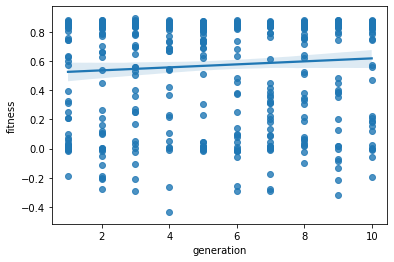

In [187]:
sns.regplot(x='gen', y='score', data=df)
plt.xlabel('generation')
plt.ylabel('fitness')
plt.savefig('f_over_g.png', dpi=600)

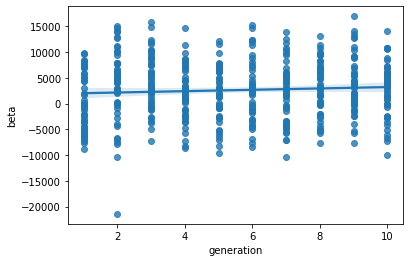

In [192]:
sns.regplot(x='gen', y='beta', data=df)
plt.xlabel('generation')
plt.ylabel('beta')
plt.savefig('b_over_g.png', dpi=600, bbox_inches='tight')